#Упражнения: Раздел 2

In [ ]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/thinkdsp.py

import thinkdsp as tdsp

--2026-05-11 22:05:24--  https://github.com/Dementrrr/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Dementrrr/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-11 22:05:25--  https://raw.githubusercontent.com/Dementrrr/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.01s   

2026-05-11 22:05:25 (4.24 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



##Упражнение 2.1
Открыл chap01.ipynb, прочитал пояснения и запустил примеры.

In [ ]:
tri_sig = tdsp.SquareSignal(freq=440, amp=1.0, offset=0)

wave = tri_sig.make_wave(duration=1, framerate=11025)
wave.apodize()
wave.make_audio()

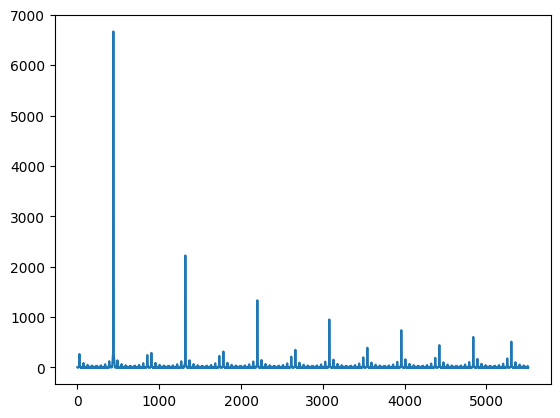

In [ ]:
spectrum = wave.make_spectrum()
spectrum.plot()

##Упражнение 2.2
Написать класс SawtoothSignal, расширяющий signal и предоставляющий evaluate для оценки сигнала

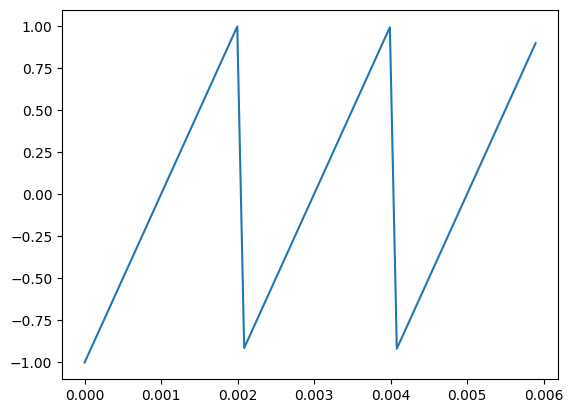

In [ ]:
import numpy as np

#класс SawtoothSignal
class SawtoothSignal(tdsp.Sinusoid):

    def evaluate(self, ts):
        cycles = self.freq * ts + self.offset / (np.pi * 2)
        frac, _ = np.modf(cycles)
        ys = tdsp.normalize(unbias(frac), self.amp)
        return ys

sawtooth = SawtoothSignal(freq=500)
sawtooth.plot()

[(np.float64(3334.032325251895), np.float64(500.0)),
 (np.float64(1667.0980587631277), np.float64(1000.0)),
 (np.float64(1111.4903836078888), np.float64(1500.0)),
 (np.float64(833.7151570542479), np.float64(2000.0)),
 (np.float64(667.0738636658649), np.float64(2500.0)),
 (np.float64(556.0006470038343), np.float64(3000.0)),
 (np.float64(476.6819089673669), np.float64(3500.0)),
 (np.float64(417.2112392491757), np.float64(4000.0)),
 (np.float64(370.9744315542131), np.float64(4500.0)),
 (np.float64(334.0035461272786), np.float64(5000.0)),
 (np.float64(303.77429381118924), np.float64(5500.0)),
 (np.float64(278.6048568953339), np.float64(5025.0)),
 (np.float64(257.3323883125339), np.float64(4525.0)),
 (np.float64(239.12852111600273), np.float64(4025.0)),
 (np.float64(223.38935887693575), np.float64(3525.0)),
 (np.float64(209.66810955390767), np.float64(3025.0)),
 (np.float64(197.63463255754738), np.float64(2525.0)),
 (np.float64(187.05660771983082), np.float64(2025.0)),
 (np.float64(177.8122

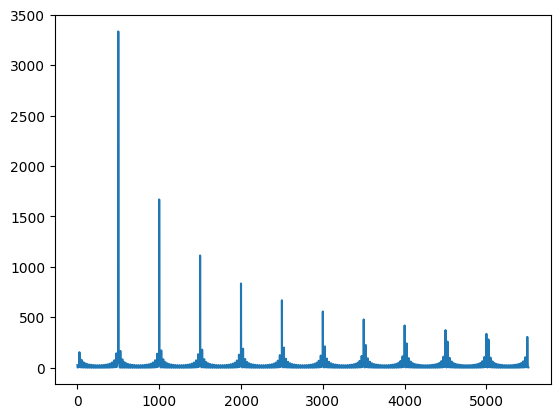

In [ ]:
#спектр пилообразного сигнала
wave = sawtooth.make_wave(duration=1, framerate=11025)
wave.apodize()
wave.make_audio()
spectrum = wave.make_spectrum()
spectrum.plot()
spectrum.peaks()[:30]

В отличии от треугольного и квадратного сигналов здесь присутствуют четные гармоники.

##Упражнение 2.3

Проверка биений в прямоугольном сигнале

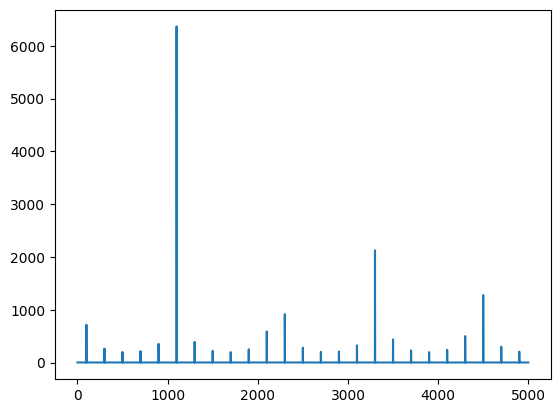

In [ ]:
square_sig = tdsp.SquareSignal(freq=1100, amp=1.0, offset=0)

wave1 = square_sig.make_wave(duration=1, framerate=10000)
spectrum1 = wave1.make_spectrum()
spectrum1.plot()
spectrum1.peaks()[:10]


Можем увидеть, что третья гармоника на 2300Гц вместо 7700Гц и так далее.

In [ ]:
#аудиальное сравнение
wave1.make_audio()

In [ ]:
wave2 = square_sig.make_wave(duration=1, framerate=40000)
wave2.make_audio()

Первый звук более глухой, так как не имеет более высоких гармоник из за более редкой выборки кадров

##Упражнение 2.4

Работа с Spectrum

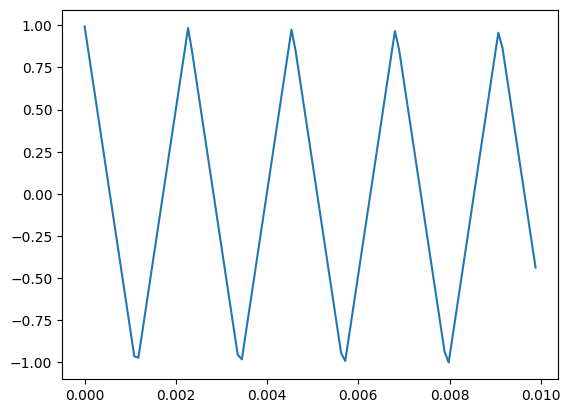

In [ ]:
#создадим треугольный сигнал и распечатаем wave
tri_sig = tdsp.TriangleSignal(freq=440, amp=1.0, offset=0)

wave = tri_sig.make_wave(duration=0.01, framerate=11025)
wave.plot()

In [ ]:
#создадим spectrum и распечатаем hs[0]
spectrum = wave.make_spectrum()
spectrum.hs[0]

np.complex128(1.0436096431476471e-14+0j)

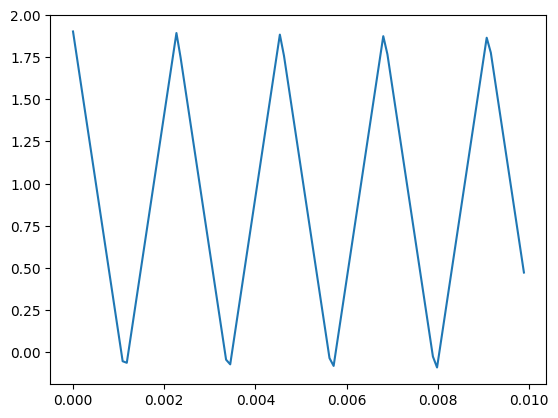

In [ ]:
#изменим hs[0] на 100 и посмотрим изменения в wave
spectrum.hs[0] = 100
wave = spectrum.make_wave()
wave.plot()


Можем заметить, что wave сдвинулся вверх, то есть hs[0] характеризует смещение относительно оси X.

##Упражнение 2.5

Функция для изменения Spectrum

In [ ]:
#функция изменения спектра
def change_spectrum (spectrum):
  spectrum.hs[0]=0
  spectrum.hs[1:] /= spectrum.fs[1:]

In [ ]:
#треугольный сигнал
wave1 = tdsp.SawtoothSignal().make_wave(duration=0.5, framerate=11025)
wave1.make_audio()

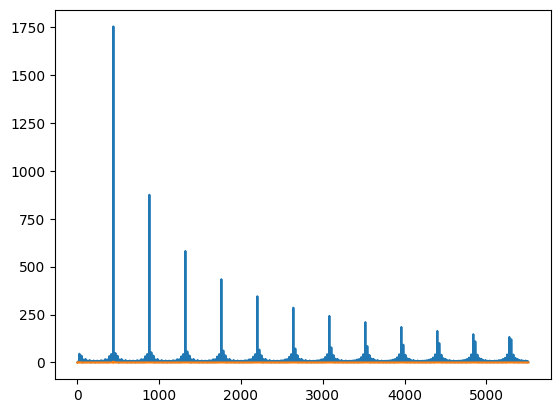

In [ ]:
spectrum1 = wave1.make_spectrum()
spectrum1.plot()
change_spectrum(spectrum1)
spectrum1.plot()

In [ ]:
spectrum1.make_wave().make_audio()

Звучание стало более мягким, приглушенным за счет меньших амплитуд и нового закона изменения амплитуды (1/f^2).

##Упражнение 2.6
Создание сигнала с четными гармониками и уменьшением пропорционально 1/f^2

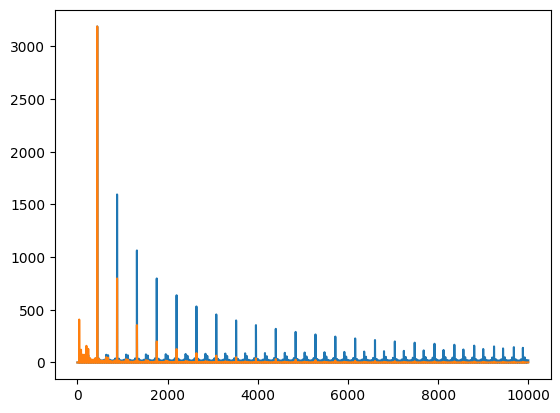

In [ ]:
#возьмем Sawtooth и изменим его
wave = tdsp.SawtoothSignal(freq=440, amp=1.0, offset=0).make_wave(duration=0.5, framerate=20000)
spectrum = wave.make_spectrum()
spectrum.plot()

#изменим спектр, используя функцию change_spectrum, чтобы изменить закон изменения амплитуды
change_spectrum(spectrum)
#вернем изначальный размер для удобного сравнения
spectrum.scale(440)
spectrum.plot()